# Урок 15.13. Теория вероятностей: случайность под контролем

**Интерактивная версия:** `lessons/lesson_15_13/web/index.html`

После урока вы сможете:

- описывать опыт пространством исходов, а события — множествами; считать классические и геометрические вероятности;
- применять правила дополнения, сложения и умножения, формулу полной вероятности и формулу Байеса (в том числе в шансах);
- отличать независимость от несовместности и разбирать парадоксы Монти Холла и Симпсона;
- описывать случайные величины законом и функцией распределения, считать матожидание, дисперсию и применять неравенство Чебышёва;
- узнавать биномиальное, геометрическое, пуассоновское, равномерное, экспоненциальное и нормальное распределения;
- генерировать случайные числа методом обратной функции;
- работать с совместным распределением, условным средним, разложением дисперсии, ковариацией и свёрткой;
- объяснять закон больших чисел, ЦПТ, их границы (тяжёлые хвосты) и цепи Маркова;
- связывать калибровку, правдоподобие, log-loss, модель шума, смещение и разброс с бустингом.

Разделы ноутбука идут в том же порядке, что и 34 шага урока (шесть блоков). Каждое числовое утверждение урока
проверяется здесь расчётом (`assert`), ключевые — сверкой со `scipy.stats`, scikit-learn и учебной библиотекой `gbcourse`.
Случайность — через генератор курса Mulberry32, как в веб-версии: числа совпадают с виджетами.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
from collections import Counter
from fractions import Fraction
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from gbcourse import datasets
from gbcourse.boosting import GBClassifier, GBRegressor
from gbcourse.ensembles import BaggingTrees
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, INK, MUTED, ORANGE, RED
from gbcourse.tree import RegressionTree

use_course_style()
np.set_printoptions(precision=4, suppress=True)
close = lambda a, b, tol=5e-4: abs(a - b) < tol

DICE = list(product(range(1, 7), repeat=2))          # 36 исходов двух кубиков
P = lambda event: Fraction(sum(1 for a, b in DICE if event(a, b)), 36)

## Интуиция: как выглядит настоящая случайность

Самая длинная серия одинаковых в 100 бросках честной монеты. Точное распределение — динамическим программированием
по длине текущей серии; сравним с симуляцией на Mulberry32.

In [2]:
def p_longest_le(n, L):
    """P(самая длинная серия одинаковых ≤ L) в n бросках честной монеты."""
    dp = np.zeros(L)
    dp[0] = 1.0                      # dp[j] — текущая серия длины j + 1
    for _ in range(n - 1):
        new = np.zeros(L)
        new[0] = 0.5 * dp.sum()
        new[1:] = 0.5 * dp[:-1]
        dp = new
    return dp.sum()

p_ge = {L: 1 - p_longest_le(100, L - 1) for L in range(4, 10)}
for L, v in p_ge.items():
    print(f"P(серия ≥ {L}) = {v:.4f}")
assert close(p_ge[5], 0.972) and close(p_ge[6], 0.807) and close(p_ge[7], 0.542) and close(p_ge[8], 0.315)

def longest(seq):
    best = cur = 1
    for a, b in zip(seq, seq[1:]):
        cur = cur + 1 if a == b else 1
        best = max(best, cur)
    return best

rng = Mulberry32(2024)
sims = [longest([rng.random() < 0.5 for _ in range(100)]) for _ in range(4000)]
print("симуляция: P(серия ≥ 5) ≈", np.mean(np.array(sims) >= 5))

P(серия ≥ 4) = 0.9997
P(серия ≥ 5) = 0.9717
P(серия ≥ 6) = 0.8068
P(серия ≥ 7) = 0.5423
P(серия ≥ 8) = 0.3148
P(серия ≥ 9) = 0.1686
симуляция: P(серия ≥ 5) ≈ 0.973


## Блок 1. Язык вероятностей

### Шаг 1. Исходы и события — множества

In [3]:
six = {(a, b) for a, b in DICE if 6 in (a, b)}
ge10 = {(a, b) for a, b in DICE if a + b >= 10}
print("|A| =", len(six), " |B| =", len(ge10), " |A ∩ B| =", len(six & ge10), " |A ∪ B| =", len(six | ge10), " |не A| =", 36 - len(six))
assert (len(six), len(ge10), len(six & ge10), len(six | ge10)) == (11, 6, 5, 12)
sum7 = {d for d in DICE if sum(d) == 7}
doubles = {d for d in DICE if d[0] == d[1]}
assert not (sum7 & doubles)                         # несовместны

|A| = 11  |B| = 6  |A ∩ B| = 5  |A ∪ B| = 12  |не A| = 25


### Шаг 2. Классическая вероятность

In [4]:
print("P(сумма 7) =", P(lambda a, b: a + b == 7), " P(11) =", P(lambda a, b: a + b == 11), " P(12) =", P(lambda a, b: a + b == 12))
t3 = Counter(sum(d) for d in product(range(1, 7), repeat=3))
print("Галилей: сумма 9 —", t3[9], " сумма 10 —", t3[10], "из 216")
assert (t3[9], t3[10]) == (25, 27)
print("ровно 2 орла из 5:", Fraction(math.comb(5, 2), 32))

P(сумма 7) = 1/6  P(11) = 1/18  P(12) = 1/36
Галилей: сумма 9 — 25  сумма 10 — 27 из 216
ровно 2 орла из 5: 5/16


### Шаг 3. Частота и закон больших чисел

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


n = 100: σ доли = 0.0500, ±2σ = 0.100
n = 10000: σ доли = 0.0050, ±2σ = 0.010
точность 0.85 на 400 объектах: σ = 0.0179


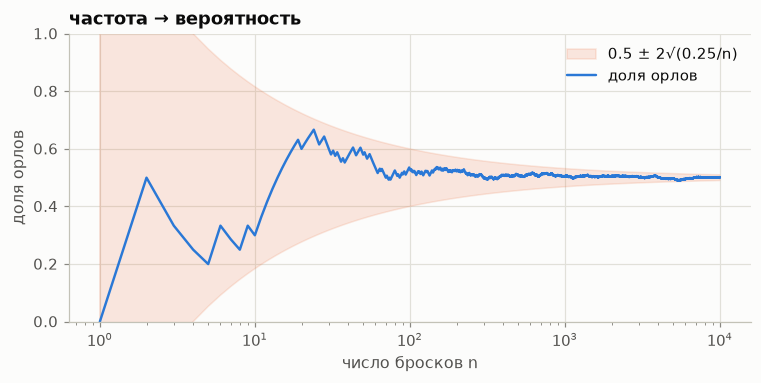

In [5]:
for n in (100, 10_000):
    print(f"n = {n}: σ доли = {math.sqrt(0.25 / n):.4f}, ±2σ = {2 * math.sqrt(0.25 / n):.3f}")
print("точность 0.85 на 400 объектах: σ =", round(math.sqrt(0.85 * 0.15 / 400), 4))
assert close(math.sqrt(0.85 * 0.15 / 400), 0.018, 1e-3)

rng = Mulberry32(1)
flips = np.array([rng.random() < 0.5 for _ in range(10_000)])
frac = flips.cumsum() / np.arange(1, 10_001)
fig, ax = plt.subplots(figsize=(8, 3.4))
n = np.arange(1, 10_001)
ax.fill_between(n, 0.5 - 2 * np.sqrt(0.25 / n), 0.5 + 2 * np.sqrt(0.25 / n), color=ORANGE, alpha=0.15, label="0.5 ± 2√(0.25/n)")
ax.plot(n, frac, color=BLUE, lw=1.6, label="доля орлов")
ax.set(xscale="log", ylim=(0, 1), xlabel="число бросков n", ylabel="доля орлов", title="частота → вероятность")
ax.legend()
plt.show()

### Шаг 4. Аксиомы и правила

In [6]:
print("хотя бы один орёл из трёх:", 1 - Fraction(1, 8))
dm1, dm2 = 1 - (5 / 6) ** 4, 1 - (35 / 36) ** 24
print(f"де Мере: {dm1:.4f} против {dm2:.4f}")
assert close(dm1, 0.518) and close(dm2, 0.491)
pA, pB, pAB = 0.5, 0.4, 0.2
print("P(A ∪ B) =", pA + pB - pAB, " ни A, ни B:", round(1 - (pA + pB - pAB), 2), " границы P(A∩B):", max(0, pA + pB - 1), min(pA, pB))
cnt = sum(1 for k in range(1, 101) if k % 2 == 0 or k % 3 == 0 or k % 5 == 0)
print("делятся на 2, 3 или 5:", cnt, "=", 50 + 33 + 20 - 16 - 10 - 6 + 3)
assert cnt == 74

хотя бы один орёл из трёх: 7/8
де Мере: 0.5177 против 0.4914
P(A ∪ B) = 0.7  ни A, ни B: 0.3  границы P(A∩B): 0 0.4
делятся на 2, 3 или 5: 74 = 74


### Шаг 5. Геометрическая вероятность: задача о встрече

In [7]:
meet = lambda t: 1 - (1 - t / 60) ** 2
print("ждать 15 мин:", meet(15), " 20 мин:", round(meet(20), 4), " для ½ нужно:", round(60 * (1 - 1 / math.sqrt(2)), 2), "мин")
assert meet(15) == 0.4375 and close(60 * (1 - 1 / math.sqrt(2)), 17.57, 0.01)
rng = Mulberry32(1)
pts = np.array([[rng.uniform(0, 60), rng.uniform(0, 60)] for _ in range(500)])
print("симуляция (500 точек, как в виджете):", np.mean(np.abs(pts[:, 0] - pts[:, 1]) <= 15))

ждать 15 мин: 0.4375  20 мин: 0.5556  для ½ нужно: 17.57 мин
симуляция (500 точек, как в виджете): 0.432


## Блок 2. Условная вероятность

### Шаг 6. Условная вероятность по таблице

In [8]:
month_churn, month_stay, year_churn, year_stay = 120, 280, 30, 570
print("P(уход) =", (month_churn + year_churn) / 1000)
print("P(уход | месячный) =", month_churn / (month_churn + month_stay), " P(уход | годовой) =", year_churn / (year_churn + year_stay))
print("P(месячный | уход) =", month_churn / (month_churn + year_churn))
print("P(сумма 8 | дубль) =", P(lambda a, b: a == b and a + b == 8) / P(lambda a, b: a == b),
      " P(дубль | сумма 8) =", P(lambda a, b: a == b and a + b == 8) / P(lambda a, b: a + b == 8))

P(уход) = 0.15
P(уход | месячный) = 0.3  P(уход | годовой) = 0.05
P(месячный | уход) = 0.8
P(сумма 8 | дубль) = 1/6  P(дубль | сумма 8) = 1/5


### Шаг 7. Правило умножения: урна

In [9]:
r, b = Fraction(3), Fraction(2)
RR, BB = r / 5 * (r - 1) / 4, b / 5 * (b - 1) / 4
mixed = 1 - RR - BB
print("без возвращения: КК", RR, " разные", mixed, " СС", BB, "  с возвращением:", (r / 5) ** 2, 2 * r / 5 * b / 5, (b / 5) ** 2)
print("второй шар красный:", r / 5 * (r - 1) / 4 + b / 5 * r / 4)
print("три туза:", Fraction(4 * 3 * 2, 52 * 51 * 50), "≈", round(24 / 132600, 6))
assert RR == Fraction(3, 10) and mixed == Fraction(3, 5) and Fraction(4 * 3 * 2, 52 * 51 * 50) == Fraction(1, 5525)

без возвращения: КК 3/10  разные 3/5  СС 1/10   с возвращением: 9/25 12/25 4/25
второй шар красный: 3/5
три туза: 1/5525 ≈ 0.000181


### Шаги 8–10. Полная вероятность, Байес, шансы

In [10]:
prior = np.array([0.5, 0.3, 0.2])
cond = np.array([0.02, 0.05, 0.10])
pA = (prior * cond).sum()
print("P(покупка) =", round(pA, 4), " P(источник | покупка) =", (prior * cond / pA).round(4))
print("брак двух заводов:", 0.6 * 0.01 + 0.4 * 0.03)

bayes = lambda prev, sens, spec: prev * sens / (prev * sens + (1 - prev) * (1 - spec))
print("P(болен | +) =", round(bayes(0.01, 0.99, 0.95), 4))
print("мошенники 2 %:", round(bayes(0.02, 0.9, 0.99), 4), "  0.2 %:", round(bayes(0.002, 0.9, 0.99), 4))
assert close(bayes(0.02, 0.9, 0.99), 0.647) and close(bayes(0.002, 0.9, 0.99), 0.153)

lr_p, lr_n = 0.99 / 0.05, 0.01 / 0.95
logit = math.log(0.01 / 0.99)
seq = [logit]
for res in "++-":
    logit += math.log(lr_p if res == "+" else lr_n)
    seq.append(logit)
probs = [1 / (1 + math.exp(-v)) for v in seq]
print("логиты:", np.round(seq, 3), " вероятности:", np.round(probs, 4))
assert close(probs[1], 1 / 6) and close(probs[2], 0.798) and close(probs[3], 0.040, 1e-3)

P(покупка) = 0.045  P(источник | покупка) = [0.2222 0.3333 0.4444]
брак двух заводов: 0.018000000000000002
P(болен | +) = 0.1667
мошенники 2 %: 0.6475   0.2 %: 0.1528
логиты: [-4.595 -1.609  1.376 -3.178]  вероятности: [0.01   0.1667 0.7984 0.04  ]


### Шаги 11–12. Независимость и парадоксы

In [11]:
print("первый чётный и сумма 7:", P(lambda a, b: a % 2 == 0 and a + b == 7), "=", P(lambda a, b: a % 2 == 0) * P(lambda a, b: a + b == 7))
print("первый чётный и сумма 8:", P(lambda a, b: a % 2 == 0 and a + b == 8), "≠", P(lambda a, b: a % 2 == 0) * P(lambda a, b: a + b == 8))
print("20 гипотез при 5 %:", round(1 - 0.95**20, 4))

rng = Mulberry32(1)                    # Монти Холл, как в виджете (1000 игр)
played = stay = 0
while played < 1000:
    car, pick = rng.randint(3), rng.randint(3)
    goats = [d for d in range(3) if d != pick and d != car]
    _ = goats[rng.randint(2)] if len(goats) == 2 else goats[0]
    played += 1
    stay += pick == car
print("Монти Холл: остаться", stay / played, " сменить", 1 - stay / played)

A = np.array([[81, 87], [192, 263]])
B = np.array([[234, 270], [55, 80]])
for name, T in (("A", A), ("B", B)):
    print(name, "по группам:", (T[:, 0] / T[:, 1]).round(3), " всего:", round(T[:, 0].sum() / T[:, 1].sum(), 3))

первый чётный и сумма 7: 1/12 = 1/12
первый чётный и сумма 8: 1/12 ≠ 5/72
20 гипотез при 5 %: 0.6415
Монти Холл: остаться 0.339  сменить 0.661
A по группам: [0.931 0.73 ]  всего: 0.78
B по группам: [0.867 0.688]  всего: 0.826


## Блок 3. Дискретные случайные величины

### Шаги 13–15. Распределение, матожидание, дисперсия, Чебышёв

In [12]:
def dist(f):
    c = Counter(f(a, b) for a, b in DICE)
    xs = sorted(c)
    return np.array(xs, dtype=float), np.array([c[x] / 36 for x in xs])

for name, f in (("сумма", lambda a, b: a + b), ("максимум", max), ("|разность|", lambda a, b: abs(a - b))):
    x, p = dist(f)
    m = (x * p).sum()
    print(f"{name:10s}: E = {m:.4f}, Var = {((x - m) ** 2 * p).sum():.4f}")
assert P(lambda a, b: a + b <= 7) == Fraction(7, 12)
assert sum(k * Fraction(2 * k - 1, 36) for k in range(1, 7)) == Fraction(161, 36)

die = np.arange(1, 7)
print("E X² =", (die**2).mean(), " Var =", die.var(), " σ =", round(die.std(), 4), " Var(2X + 3) =", round((2 * die + 3).var(), 4))
print("различных граней в 6 бросках:", round(6 * (1 - (5 / 6) ** 6), 4), "  шестёрок в 10 бросках:", round(10 / 6, 4))
b20 = stats.binom(20, 0.5)
tail = b20.cdf(5) + b20.sf(14)
print("Bin(20, 0.5): P(|X − 10| ≥ 2σ) =", round(tail, 4), "≤ 0.25")
assert close(tail, 0.0414)

сумма     : E = 7.0000, Var = 5.8333
максимум  : E = 4.4722, Var = 1.9715
|разность|: E = 1.9444, Var = 2.0525
E X² = 15.166666666666666  Var = 2.9166666666666665  σ = 1.7078  Var(2X + 3) = 11.6667
различных граней в 6 бросках: 3.9906   шестёрок в 10 бросках: 1.6667
Bin(20, 0.5): P(|X − 10| ≥ 2σ) = 0.0414 ≤ 0.25


### Шаги 16–18. Бернулли, бином, геометрическое, Пуассон

P(5 из 10) = 0.2461  Bin(10, .3) P(3) = 0.2668
20 клиентов: E = 3.0  Var = 2.55  P(0) = 0.0388  P(X ≥ 5) = 0.1702
шестёрка: P(X > 10) = 0.1615  P(X ≤ 3) = 0.4213  P(X ≤ 4) = 0.5177
опечатки λ = 2: P(0) = 0.1353  P(≥ 3) = 0.3233
Bin(100, 0.03) P(3) = 0.2275  Pois(3) P(3) = 0.224
  TV(Bin(10, 3/n), Pois(3)) = 0.0864
  TV(Bin(30, 3/n), Pois(3)) = 0.0262
  TV(Bin(100, 3/n), Pois(3)) = 0.0076
  TV(Bin(1000, 3/n), Pois(3)) = 0.0008


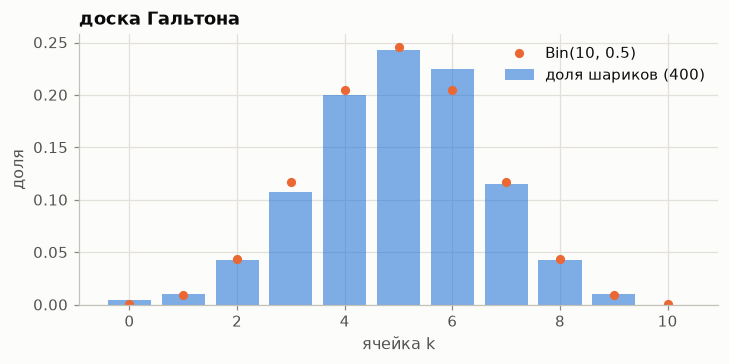

In [13]:
print("P(5 из 10) =", round(stats.binom.pmf(5, 10, 0.5), 4), " Bin(10, .3) P(3) =", round(stats.binom.pmf(3, 10, 0.3), 4))
b = stats.binom(20, 0.15)
print("20 клиентов: E =", b.mean(), " Var =", round(b.var(), 4), " P(0) =", round(b.pmf(0), 4), " P(X ≥ 5) =", round(b.sf(4), 4))
assert close(b.sf(4), 0.170) and close(b.pmf(0), 0.039)
print("шестёрка: P(X > 10) =", round((5 / 6) ** 10, 4), " P(X ≤ 3) =", round(1 - (5 / 6) ** 3, 4), " P(X ≤ 4) =", round(1 - (5 / 6) ** 4, 4))
print("опечатки λ = 2: P(0) =", round(math.exp(-2), 4), " P(≥ 3) =", round(stats.poisson(2).sf(2), 4))
print("Bin(100, 0.03) P(3) =", round(stats.binom.pmf(3, 100, 0.03), 4), " Pois(3) P(3) =", round(stats.poisson.pmf(3, 3), 4))
k = np.arange(60)
for n in (10, 30, 100, 1000):
    print(f"  TV(Bin({n}, 3/n), Pois(3)) = {0.5 * np.abs(stats.binom.pmf(k, n, 3 / n) - stats.poisson.pmf(k, 3)).sum():.4f}")

rng = Mulberry32(1)                    # доска Гальтона: 400 шариков, 10 рядов
bins = np.bincount([sum(rng.random() < 0.5 for _ in range(10)) for _ in range(400)], minlength=11)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(range(11), bins / 400, color=BLUE, alpha=0.6, label="доля шариков (400)")
ax.plot(range(11), stats.binom.pmf(range(11), 10, 0.5), "o", color=ORANGE, label="Bin(10, 0.5)")
ax.set(xlabel="ячейка k", ylabel="доля", title="доска Гальтона")
ax.legend()
plt.show()

## Блок 4. Непрерывные величины

### Шаги 19–22. Плотность, экспоненциальное, нормальное, генерация

In [14]:
E = stats.expon(scale=2)
print("Exp(0.5): P(X > 3) =", round(E.sf(3), 4), " медиана =", round(E.median(), 4), " среднее =", E.mean())
assert close(E.sf(3), 0.223) and close(E.median(), 1.386)
for kk in (1, 2, 3):
    print(f"P(|Z| < {kk}) = {stats.norm.cdf(kk) - stats.norm.cdf(-kk):.4f}")
N = stats.norm(170, 8)
print("рост > 186:", round(N.sf(186), 4), " 160…180:", round(N.cdf(180) - N.cdf(160), 4), " q(0.975) =", round(stats.norm.ppf(0.975), 3))
assert close(N.sf(186), 0.023) and close(N.cdf(180) - N.cdf(160), 0.789)

u = Mulberry32(42).random()
print("Mulberry32(42): u =", round(u, 6), " → Exp(1):", round(-math.log(1 - u), 4))
assert close(u, 0.601104, 1e-6) and close(-math.log(1 - u), 0.919)

# пуассоновский поток: среднее ожидание пассажира ≈ среднему интервалу, «пойманный» интервал ≈ 2/λ
rng = Mulberry32(1)
lam, T = 0.1, 20000
ev, t = [], -math.log(1 - rng.random()) / lam
while t < T + 200:
    ev.append(t)
    t += -math.log(1 - rng.random()) / lam
ev = np.array(ev)
pas = np.sort([rng.uniform(0, T) for _ in range(5000)])
j = np.searchsorted(ev, pas)
ok = (j > 0) & (j < len(ev))
print(f"интервал {np.diff(ev).mean():.2f}, ожидание {(ev[j[ok]] - pas[ok]).mean():.2f}, пойманный интервал {(ev[j[ok]] - ev[j[ok] - 1]).mean():.2f}")

Exp(0.5): P(X > 3) = 0.2231  медиана = 1.3863  среднее = 2.0
P(|Z| < 1) = 0.6827
P(|Z| < 2) = 0.9545
P(|Z| < 3) = 0.9973
рост > 186: 0.0228  160…180: 0.7887  q(0.975) = 1.96
Mulberry32(42): u = 0.601104  → Exp(1): 0.9191
интервал 9.71, ожидание 10.04, пойманный интервал 19.52


## Блок 5. Несколько величин и предельные теоремы

### Шаги 23–24. Совместное распределение, условное среднее, разложение дисперсии

In [15]:
J = np.array([[0.3 * 0.8, 0.3 * 0.2], [0.7 * 0.2, 0.7 * 0.8]])      # дождь/сухо × зонт/без
px, py = J.sum(1), J.sum(0)
print("P(зонт) =", py[0], " P(дождь | зонт) =", round(J[0, 0] / py[0], 4), " независимы:", np.allclose(J, np.outer(px, py)))

y = np.array([2, 4, 3, 7, 9, 11.0])
g = np.array([0, 0, 0, 1, 1, 1])
means = np.array([y[g == 0].mean(), y[g == 1].mean()])
within = ((y - means[g]) ** 2).mean()
print(f"Var Y = {y.var():.4f} = внутри {within:.4f} + между {y.var() - within:.4f};  выигрыш разбиения {6 * (y.var() - within):.1f}")
assert close(y.var(), 64 / 6) and close(within, 5 / 3) and close(6 * (y.var() - within), 54)
tree = RegressionTree(max_depth=1).fit(np.arange(1, 7.0).reshape(-1, 1), -y)
print("корневое разбиение gbcourse даёт листья:", np.unique(tree.predict(np.arange(1, 7.0).reshape(-1, 1))))

P(зонт) = 0.38  P(дождь | зонт) = 0.6316  независимы: False
Var Y = 10.6667 = внутри 1.6667 + между 9.0000;  выигрыш разбиения 54.0
корневое разбиение gbcourse даёт листья: [3. 9.]


### Шаги 25–26. Ковариация, корреляция, свёртка

In [16]:
x = np.array([-2, -1, 0, 1, 2.0])
print("cov(X, X²) =", np.cov(x, x**2, bias=True)[0, 1], " corr(первый кубик, сумма) =", round(1 / math.sqrt(2), 4))
pm = np.array([1.0])
for _ in range(3):
    pm = np.convolve(pm, np.full(6, 1 / 6))
print("три кубика (свёртка): P(9) =", round(pm[9 - 3] * 216), "/216, P(10) =", round(pm[10 - 3] * 216), "/216")

cov(X, X²) = 0.0  corr(первый кубик, сумма) = 0.7071
три кубика (свёртка): P(9) = 25 /216, P(10) = 27 /216


### Шаги 27–28. Закон больших чисел, тяжёлые хвосты, ЦПТ

Чебышёв (1000 бросков, ε = 0.05): 0.1  точно: 0.0017
σ/√n для кубика: [1.7078, 0.8539, 0.427, 0.2135]
100 монет, P(X ≥ 60): точно 0.0284  нормально 0.0228  с поправкой 0.0287
4000 средних по 16 бросков: разброс 0.4245  теория 0.427


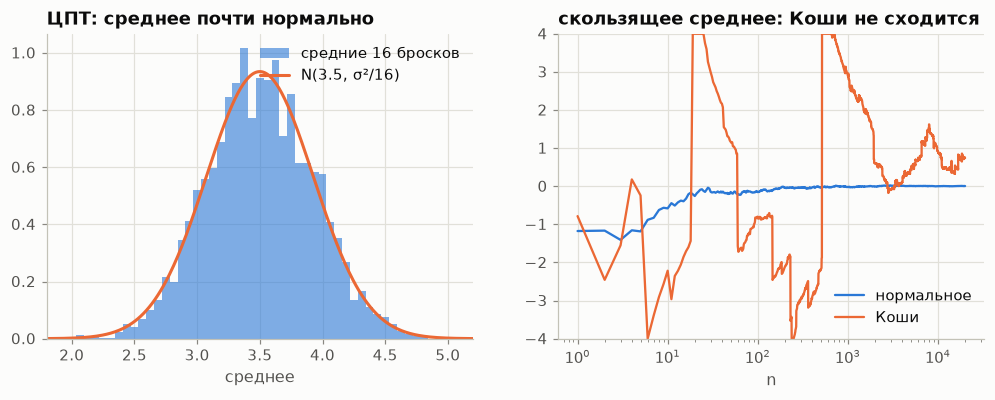

In [17]:
print("Чебышёв (1000 бросков, ε = 0.05):", 0.25 / (1000 * 0.0025), " точно:", round(stats.binom(1000, 0.5).cdf(450) + stats.binom(1000, 0.5).sf(549), 4))
print("σ/√n для кубика:", [round(math.sqrt(35 / 12 / n), 4) for n in (1, 4, 16, 64)])
print("100 монет, P(X ≥ 60): точно", round(stats.binom.sf(59, 100, 0.5), 4), " нормально", round(stats.norm.sf(2), 4), " с поправкой", round(stats.norm.sf(1.9), 4))

rng = Mulberry32(5)
means = np.array([np.mean([1 + rng.randint(6) for _ in range(16)]) for _ in range(4000)])
print("4000 средних по 16 бросков: разброс", round(means.std(), 4), " теория", round(math.sqrt(35 / 12 / 16), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
xx = np.linspace(1.8, 5.2, 300)
ax.hist(means, bins=np.arange(1 - 1 / 32, 6 + 1 / 16, 1 / 16), density=True, color=BLUE, alpha=0.6, label="средние 16 бросков")
ax.plot(xx, stats.norm.pdf(xx, 3.5, math.sqrt(35 / 12 / 16)), color=ORANGE, lw=2, label="N(3.5, σ²/16)")
ax.set(xlim=(1.8, 5.2), title="ЦПТ: среднее почти нормально", xlabel="среднее")
ax.legend()
ax = axes[1]
for kind, col in (("нормальное", BLUE), ("Коши", ORANGE)):
    rng = Mulberry32(11 if kind == "нормальное" else 12)
    v = [rng.normal() if kind == "нормальное" else math.tan(math.pi * (rng.random() - 0.5)) for _ in range(20000)]
    ax.plot(np.arange(1, 20001), np.clip(np.cumsum(v) / np.arange(1, 20001), -4, 4), color=col, lw=1.5, label=kind)
ax.set(xscale="log", ylim=(-4, 4), title="скользящее среднее: Коши не сходится", xlabel="n")
ax.legend()
plt.show()

### Шаг 29. Цепь Маркова

In [18]:
Pm = np.array([[0.9, 0.1], [0.5, 0.5]])
v = np.array([0, 1.0])
for t in range(1, 11):
    v = v @ Pm
    if t in (1, 2, 3, 10):
        print(f"t = {t}: {v.round(5)}")
assert np.allclose(v, [0.83325, 0.16675], atol=1e-5)
w, V = np.linalg.eig(Pm.T)
pi = np.real(V[:, np.argmin(abs(w - 1))])
print("стационарное π =", (pi / pi.sum()).round(5), " второе собственное число:", round(sorted(np.real(w))[0], 3))

t = 1: [0.5 0.5]
t = 2: [0.7 0.3]
t = 3: [0.78 0.22]
t = 10: [0.8333 0.1668]
стационарное π = [0.8333 0.1667]  второе собственное число: 0.4


## Блок 6. Вероятность в машинном обучении

### Шаг 30. Калибровка: сверка со scikit-learn

In [19]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

rng = Mulberry32(11)
z = np.empty(4000)
yc = np.empty(4000)
for i in range(4000):
    z[i] = 1.6 * rng.normal()
    yc[i] = rng.random() < 1 / (1 + np.exp(-z[i]))
for T in (0.5, 1.0, 2.0):
    p = 1 / (1 + np.exp(-z / T))
    print(f"T = {T}: log-loss {log_loss(yc, p):.4f}, Брайер {brier_score_loss(yc, p):.4f}, AUC {roc_auc_score(yc, p):.4f}")
frac_pos, mean_pred = calibration_curve(yc, 1 / (1 + np.exp(-z / 0.5)), n_bins=10)
print("самоуверенная модель (T = 0.5), корзины:", np.c_[mean_pred, frac_pos].round(3)[:3], "…")
print("прогноз 0.99 при ответе 0 стоит", round(-math.log(0.01), 2), "ната")

T = 0.5: log-loss 0.5967, Брайер 0.1857, AUC 0.8199
T = 1.0: log-loss 0.5188, Брайер 0.1732, AUC 0.8199
T = 2.0: log-loss 0.5514, Брайер 0.1843, AUC 0.8199
самоуверенная модель (T = 0.5), корзины: [[0.033 0.132]
 [0.149 0.277]
 [0.245 0.385]] …
прогноз 0.99 при ответе 0 стоит 4.61 ната


### Шаг 31. Правдоподобие и log-loss; стартовый логит `gbcourse`

In [20]:
yb = np.array([1, 1, 0, 1, 1, 0, 1, 1, 0, 1.0])
ll = lambda p: -np.mean(yb * np.log(p) + (1 - yb) * np.log(1 - p))
print("L(0.7) =", round(0.7**7 * 0.3**3, 6), " log-loss: 0.5 →", round(ll(0.5), 4), " 0.7 →", round(ll(0.7), 4), " 0.9 →", round(ll(0.9), 4))
m = GBClassifier(n_estimators=1, learning_rate=0.1, max_depth=1).fit(np.zeros((10, 1)), yb.astype(int))
print("F0 = ln(7/3) =", round(math.log(7 / 3), 4), " gbcourse:", round(float(m.init_), 4))
assert close(float(m.init_), math.log(7 / 3), 1e-9) and close(ll(0.7), 0.611)

L(0.7) = 0.002224  log-loss: 0.5 → 0.6931  0.7 → 0.6109  0.9 → 0.7645
F0 = ln(7/3) = 0.8473  gbcourse: 0.8473


### Шаг 32. Модель шума и лучшая константа

In [21]:
from scipy.optimize import minimize_scalar

for name, data in (("квартиры", np.array([2, 4, 3, 7, 9, 11.0])), ("с выбросом", np.array([2, 4, 3, 7, 9, 21.0]))):
    print(f"{name}: среднее {data.mean():.3f}, медиана {np.median(data)}")
counts = np.array([0, 1, 1, 2, 3, 0, 5, 2, 1, 8.0])
r = minimize_scalar(lambda F: np.mean(np.exp(F) - counts * F), bounds=(-3, 3), method="bounded")
print("пуассоновские потери: оптимальный F =", round(r.x, 4), " ln(среднего) =", round(math.log(counts.mean()), 4))
gbp = GBRegressor(loss="poisson", n_estimators=1, learning_rate=0.1, max_depth=1).fit(np.zeros((10, 1)), counts)
print("стартовая константа gbcourse (poisson):", round(float(gbp.init_), 4))
assert close(float(gbp.init_), math.log(counts.mean()), 1e-9)

# XGBoost count:poisson: гессиан e^(F + max_delta_step); при max_delta_step = 0 — ровно λ = e^F
import xgboost as xgb

dm = xgb.DMatrix(np.zeros((10, 1)), label=counts)
F0, mu0 = math.log(0.5), 0.5
newton = math.exp(F0 - (mu0 - counts).sum() / (mu0 * 10))          # один шаг Ньютона из F0 = ln 0.5
for mds in (0, 0.7):
    bst = xgb.train({"objective": "count:poisson", "base_score": 0.5, "eta": 1, "lambda": 0, "min_child_weight": 0, "max_delta_step": mds}, dm, 1)
    print(f"max_delta_step = {mds}: прогноз XGBoost {bst.predict(dm)[0]:.4f}")
print("шаг Ньютона с гессианом λ:", round(newton, 4), "; с ограничением шага 0.7:", round(math.exp(F0 + 0.7), 4))

квартиры: среднее 6.000, медиана 5.5
с выбросом: среднее 7.667, медиана 5.5
пуассоновские потери: оптимальный F = 0.8329  ln(среднего) = 0.8329
стартовая константа gbcourse (poisson): 0.8329
max_delta_step = 0: прогноз XGBoost 18.2991
max_delta_step = 0.7: прогноз XGBoost 1.0069
шаг Ньютона с гессианом λ: 18.2991 ; с ограничением шага 0.7: 1.0069


### Шаг 33. Смещение и разброс: деревья, бэггинг, бустинг

40 обучающих выборок по 40 точек $y = \sin x + \varepsilon$, $\sigma = 0.4$ — тот же опыт, что в виджете.

tree  глубина 1: смещение² 0.280, разброс 0.112, сумма + шум 0.552
tree  глубина 2: смещение² 0.071, разброс 0.109, сумма + шум 0.339
tree  глубина 3: смещение² 0.015, разброс 0.117, сумма + шум 0.292
tree  глубина 4: смещение² 0.009, разброс 0.122, сумма + шум 0.291
tree  глубина 5: смещение² 0.007, разброс 0.143, сумма + шум 0.310
tree  глубина 6: смещение² 0.008, разброс 0.157, сумма + шум 0.325
tree  глубина 7: смещение² 0.008, разброс 0.166, сумма + шум 0.334
tree  глубина 8: смещение² 0.007, разброс 0.168, сумма + шум 0.336
bag   глубина 1: смещение² 0.270, разброс 0.071, сумма + шум 0.501
boost глубина 1: смещение² 0.122, разброс 0.038, сумма + шум 0.320
bag   глубина 3: смещение² 0.019, разброс 0.060, сумма + шум 0.239
boost глубина 3: смещение² 0.008, разброс 0.106, сумма + шум 0.274
bag   глубина 8: смещение² 0.009, разброс 0.087, сумма + шум 0.256
boost глубина 8: смещение² 0.007, разброс 0.168, сумма + шум 0.335


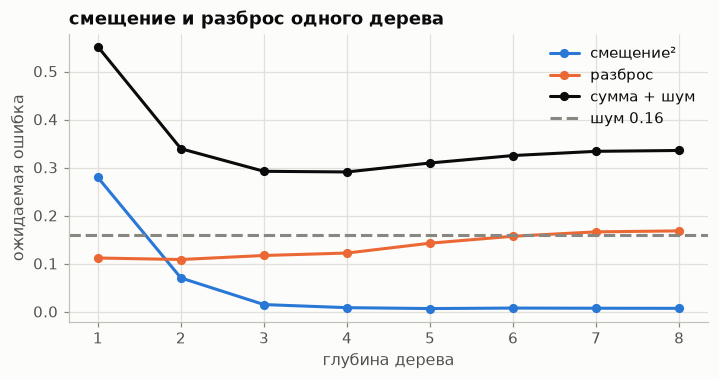

In [22]:
grid = np.linspace(0, 10, 101)
def bias_var(make, K=40):
    Pr = []
    for seed in range(1, K + 1):
        X, yy = datasets.regression_1d(kind="sine", n=40, noise=0.4, seed=seed)
        Pr.append(make(seed).fit(X, yy).predict(grid.reshape(-1, 1)))
    Pr = np.array(Pr)
    return ((Pr.mean(0) - np.sin(grid)) ** 2).mean(), Pr.var(0).mean()

class Tree:
    """Одно дерево: g = −y, поэтому значения листьев — средние."""

    def __init__(self, d):
        self.t = RegressionTree(max_depth=d)
    def fit(self, X, yy):
        self.t.fit(X, -yy)
        return self.t

res = {}
for d in range(1, 9):
    res[("tree", d)] = bias_var(lambda s, d=d: Tree(d))
for d in (1, 3, 8):
    res[("bag", d)] = bias_var(lambda s, d=d: BaggingTrees(n_estimators=25, max_depth=d, seed=1000 + s))
    res[("boost", d)] = bias_var(lambda s, d=d: GBRegressor(n_estimators=50, learning_rate=0.1, max_depth=d))
for key, (b2, vr) in res.items():
    print(f"{key[0]:5s} глубина {key[1]}: смещение² {b2:.3f}, разброс {vr:.3f}, сумма + шум {b2 + vr + 0.16:.3f}")
assert close(res[("tree", 1)][0], 0.280, 1e-3) and close(res[("tree", 1)][1], 0.112, 1e-3)
assert close(res[("tree", 8)][1], 0.168, 1e-3) and close(res[("bag", 8)][1], 0.087, 1e-3) and close(res[("boost", 1)][0], 0.122, 1e-3)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ds = range(1, 9)
ax.plot(ds, [res[("tree", d)][0] for d in ds], "o-", color=BLUE, label="смещение²")
ax.plot(ds, [res[("tree", d)][1] for d in ds], "o-", color=ORANGE, label="разброс")
ax.plot(ds, [sum(res[("tree", d)]) + 0.16 for d in ds], "o-", color=INK, label="сумма + шум")
ax.axhline(0.16, color=MUTED, ls="--", label="шум 0.16")
ax.set(xlabel="глубина дерева", ylabel="ожидаемая ошибка", title="смещение и разброс одного дерева")
ax.legend()
plt.show()

### Шаг 34. Дисперсия среднего и бутстрэп

In [23]:
print("ρ = 0.3, k = 10:", 0.3 + 0.7 / 10, "   ρ = 0.2, k = 50:", 0.2 + 0.8 / 50)
for n in (10, 100, 1000):
    print(f"OOB n = {n}: {(1 - 1 / n) ** n:.4f}")
rho, k, T = 0.3, 10, 2000
rng = Mulberry32(1 + k)           # то же зерно, что в виджете
mm = np.empty(T)
for t in range(T):
    c = rng.normal()
    mm[t] = np.mean([math.sqrt(rho) * c + math.sqrt(1 - rho) * rng.normal() for _ in range(k)])
print("симуляция дисперсии среднего:", round(mm.var(), 4), " формула:", rho + (1 - rho) / k)
bag = BaggingTrees(n_estimators=1, max_depth=None, seed=0).fit(np.arange(100.0).reshape(-1, 1), np.zeros(100))
print("доля OOB в первом бутстрэпе gbcourse (n = 100):", (bag.inbag_counts_[0] == 0).mean())

ρ = 0.3, k = 10: 0.37    ρ = 0.2, k = 50: 0.21600000000000003
OOB n = 10: 0.3487
OOB n = 100: 0.3660
OOB n = 1000: 0.3677
симуляция дисперсии среднего: 0.3711  формула: 0.37
доля OOB в первом бутстрэпе gbcourse (n = 100): 0.41


## Упражнения

Задачи — в `exercises/tasks.md`, решения — в `exercises/solutions.py`. Попробуйте сначала решить сами:
1) вероятность серии ≥ 6 в 50 бросках; 2) Байес для теста с двумя результатами; 3) ожидание числа бросков до всех
шести граней; 4) дисперсия суммы зависимых величин; 5) калибровка самоуверенной модели.